# StatBridge 골든셋 v1 — 직접 검증 노트북

이 노트북은 `eval/statbridge-golden/v1/`의 골든셋을 **눈으로 확인**하기 위한 것입니다. 표준 라이브러리만으로 동작하며, pandas/matplotlib은 있으면 선택적으로 씁니다.

**미리 알면 좋은 것**
- 골든셋 한 줄 = `input`(문제) + `gold`(정답, 9계층).
- 채점은 `scripts/score.py`가 합니다. 각 계층이 `exact`(맞음/틀림)이고, **labeled 계층이 전부 맞아야 `correct`** 입니다.
- 함정(`forbidden`)에 걸리면 즉시 `forbidden_hit`, 그 외 어긋나면 `mismatch`.
- 정답의 우주 = KOSIS 한국은행 349표. `research/`는 질문 소재일 뿐입니다.

실행: 커널에서 위에서부터 차례로 실행하세요(Shift+Enter).

## 0. 경로 설정 · 임포트

노트북 위치가 어디든 리포 루트를 찾아 `scripts/`를 import 경로에 넣습니다.

In [1]:
from pathlib import Path
import sys, json, tempfile, copy


def find_root(start):
    p = Path(start).resolve()
    for cand in [p, *p.parents]:
        if (cand / "eval/statbridge-golden/v1/scripts/score.py").is_file():
            return cand
    raise FileNotFoundError("StatBridge repo root not found (리포 안에서 실행하세요)")


ROOT = find_root(Path.cwd())
V1 = ROOT / "eval/statbridge-golden/v1"
sys.path.insert(0, str(V1 / "scripts"))
import validate as V   # scripts/validate.py
import score as S      # scripts/score.py

print("ROOT:", ROOT)
print("V1  :", V1)


ROOT: C:\Users\cheon\orca\StatBridge-local
V1  : C:\Users\cheon\orca\StatBridge-local\eval\statbridge-golden\v1


## 1. 문제 불러오기 (input = 문제)

In [2]:
records = S.load(V1 / "cases/dev.jsonl")
print("문제 수:", len(records))
for r in records:
    print("=" * 80)
    print("id   :", r["id"], "| split:", r["split"])
    print("query:", r["input"]["query"])
    print("gold :", list(r["gold"].keys()))


문제 수: 2
id   : GS2-0001 | split: dev
query: 2025년 경제심리지수 순환변동치 월별 추이 보여주고 해석해줘
gold : ['e2e_kpi', 'slots', 'concepts', 'clarification', 'plan', 'discovery', 'numeric', 'graph', 'interpretation']
id   : GS2-0042 | split: dev
query: 2025년 수출물가지수와 수입물가지수 원화기준 흐름을 비교해서 보여주고 해석해줘
gold : ['e2e_kpi', 'slots', 'concepts', 'clarification', 'plan', 'discovery', 'numeric', 'graph', 'interpretation']


In [ ]:
# 리뷰용 요약: dev 전체를 한눈에 (검수 시 사용)
print(f"{'id':9} {'split':5} {'status':10} {'tables':28} {'graph':16} {'#claims':7} approved")
for r in records:
    g = r['gold']; d = g['discovery']; gr = g.get('graph', {}); iv = g.get('interpretation', {})
    gtxt = f"{gr.get('chart_type','-')}/{gr.get('layout','-')}" if gr.get('status') == 'labeled' else '-'
    nc = len(iv.get('required_claims', [])) if iv.get('status') == 'labeled' else 0
    tbl = ','.join(d.get('acceptable_table_ids', []))
    print(f"{r['id']:9} {r['split']:5} {d.get('expected_status',''):10} {tbl[:28]:28} {gtxt:16} {nc:<7} {r['review']['human_approved']}")


### 1-1. 한 문제 전체 보기 (input vs gold)

`rid`를 바꾸면 다른 문제를 볼 수 있습니다.

In [3]:
rid = records[0]["id"]     # "GS2-0042" 로 바꿔 보세요
rec = next(r for r in records if r["id"] == rid)
print(json.dumps(rec, ensure_ascii=False, indent=2))


{
  "id": "GS2-0001",
  "schema_version": "gs1",
  "split": "dev",
  "source": {
    "publisher": "한국은행",
    "publication": "통화신용정책보고서",
    "doc_id": "2026-09-10_통화신용정책보고서(2026년 9월)",
    "locator": "경제심리 및 성장 설명",
    "url": "https://www.bok.or.kr/portal/bbs/B0000156/view.do?menuNo=200067&nttId=11064613"
  },
  "input": {
    "prior_turns": [],
    "query": "2025년 경제심리지수 순환변동치 월별 추이 보여주고 해석해줘"
  },
  "gold": {
    "e2e_kpi": {
      "status": "labeled",
      "pass": true,
      "final_output": "그래프 + 해석"
    },
    "slots": {
      "status": "labeled",
      "metric": "경제심리지수 순환변동치",
      "target": "경제심리지수",
      "period": {
        "type": "absolute",
        "start": "2025-01",
        "end": "2025-12"
      },
      "frequency": "M"
    },
    "concepts": {
      "status": "labeled",
      "acceptable_concepts": [
        "경제심리지수",
        "경제심리지수 순환변동치",
        "ESI"
      ]
    },
    "clarification": {
      "status": "labeled",
      "need_clarification": false
    },
   

## 2. 문제지 자체 검사 (validator)

`0 errors`면 문제지가 규칙(구조·누수·fixture 해시·함정 정합성)을 지켰다는 뜻입니다.

In [4]:
errs = V.validate_all()
print("validator errors:", len(errs))
for e in errs:
    print(" -", e)
print("OK: 0 errors" if not errs else "문제 있음")


validator errors: 0
OK: 0 errors


## 3. 그래프 숫자 원본 (fixture)

fixture는 로컬 CSV에서 뽑은 스냅샷입니다(원본 CSV 해시 포함).

In [5]:
for fx_path in sorted((V1 / "fixtures").glob("*.json")):
    fx = json.loads(fx_path.read_text(encoding="utf-8"))
    print("=" * 80)
    print(fx_path.name, "| snapshot:", fx.get("snapshot_id"))
    for s in fx["series"]:
        pts = s["points"]
        head = ", ".join(f"{p['period']}={p['value']}" for p in pts[:4])
        print(f"  [{s['table_id']}] {s.get('label','')} "
              f"(freq={s.get('frequency')}, unit={s.get('unit')}) points={len(pts)}")
        print("     ", head, "...")


esi-2025.json | snapshot: statbridge-local-csv-frozen-2026-09-28
  [DT_513Y001] 경제심리지수 순환변동치 (freq=M, unit=) points=12
      202501=89.8, 202502=89.6, 202503=89.6, 202504=89.9 ...
trade_price_2025.json | snapshot: statbridge-local-csv-frozen-2026-09-28
  [DT_402Y014] 수출물가지수(원화기준) (freq=M, unit=2020=100) points=12
      202501=135.31, 202502=134.56, 202503=135.11, 202504=133.05 ...
  [DT_401Y015] 수입물가지수(원화기준) (freq=M, unit=2020=100) points=12
      202501=145.08, 202502=143.6, 202503=143.04, 202504=139.82 ...


(선택) matplotlib이 있으면 선그래프로도 확인합니다.

C:\Users\cheon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cheon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cheon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cheon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cheon\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io,

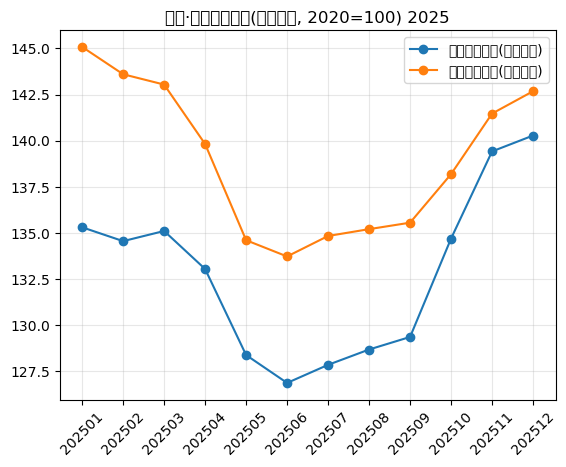

In [6]:
try:
    import matplotlib.pyplot as plt
    fx = json.loads((V1 / "fixtures/trade_price_2025.json").read_text(encoding="utf-8"))
    for s in fx["series"]:
        xs = [p["period"] for p in s["points"]]
        ys = [p["value"] for p in s["points"]]
        plt.plot(xs, ys, marker="o", label=s.get("label") or s["table_id"])
    plt.title("수출·수입물가지수(원화기준, 2020=100) 2025")
    plt.legend(); plt.xticks(rotation=45); plt.grid(True, alpha=0.3); plt.show()
except ModuleNotFoundError:
    print("matplotlib 없음 → 이 셀은 건너뜀 (선택 사항)")


## 4. 채점 시연 A — 정답 답안 (전부 correct)

골든셋의 정답을 그대로 "예측"으로 넣으면 채점기는 전부 `correct`여야 합니다(자기일관성 검사).

In [7]:
def gold_echo_pred(r):
    G = r["gold"]; d = G["discovery"]; g = G.get("graph", {})
    fx = {"series": []}
    if g.get("status") == "labeled":
        fx = json.loads((V1 / g["fixture"]).read_text(encoding="utf-8"))
    s = G.get("slots", {}); c = G.get("concepts", {}); cl = G.get("clarification", {})
    pl = G.get("plan", {}); e = G.get("e2e_kpi", {})
    return {
        "id": r["id"],
        "status": d.get("expected_status"), "table_ids": d.get("acceptable_table_ids", []),
        "slots": {k: s[k] for k in ("metric", "metrics", "target", "frequency", "basis", "period") if k in s},
        "concepts": {"concepts": c.get("acceptable_concepts", [])},
        "clarification": {"asked": cl.get("need_clarification", False),
                          "options": cl.get("acceptable_options", [])},
        "plan": {"tool_sequences": pl.get("acceptable_tool_sequences", [])},
        "e2e": {"pass": e.get("pass")},
        "graph": {"chart_type": g.get("chart_type"), "layout": g.get("layout"), "series": fx["series"]},
        "numeric": {"series": fx["series"]},
        "interpretation": {"claims": G.get("interpretation", {}).get("required_claims", [])},
    }


def run_score(preds):
    tmp = Path(tempfile.mkdtemp())
    pred_path = tmp / "pred.jsonl"
    pred_path.write_text("".join(json.dumps(p, ensure_ascii=False) + "\n" for p in preds),
                         encoding="utf-8")
    return S.score(V1 / "cases/dev.jsonl", pred_path, out_dir=tmp), tmp


preds_ok = [gold_echo_pred(r) for r in records]
res_ok, tmp_ok = run_score(preds_ok)
print(json.dumps(res_ok["summary"], ensure_ascii=False, indent=2))
for c in res_ok["cases"]:
    print(c["id"], "->", c["grade"], "| 계층 exact:",
          {k: v.get("exact") for k, v in c["layers"].items()})


{
  "n": 2,
  "correct": 2,
  "forbidden_hit": 0,
  "mismatch": 0
}
GS2-0001 -> correct | 계층 exact: {'slots': True, 'concepts': True, 'clarification': True, 'plan': True, 'e2e_kpi': True, 'discovery': True, 'numeric': True, 'graph': True, 'interpretation': True}
GS2-0042 -> correct | 계층 exact: {'slots': True, 'concepts': True, 'clarification': True, 'plan': True, 'e2e_kpi': True, 'discovery': True, 'numeric': True, 'graph': True, 'interpretation': True}


## 5. 채점 시연 B — 일부러 틀린 답안

- 정답과 다른 표(금지된 sibling)를 고르면 → `forbidden_hit`
- 방향을 뒤집는 환각 문장을 넣으면 → `forbidden_hit`
- 표는 맞지만 그래프 종류를 틀리면 → `mismatch`

In [8]:
preds_bad = copy.deepcopy(preds_ok)

# (1) GS2-0001: 엉뚱한 표(금지 목록의 sibling) 선택
for p in preds_bad:
    if p["id"] == "GS2-0001":
        p["table_ids"] = ["DT_512Y013"]     # 기업경기실사지수 (forbidden_table_ids)

# (2) GS2-0042: 방향을 뒤집는 환각 주장
for p in preds_bad:
    if p["id"] == "GS2-0042":
        p["interpretation"] = {"claims": [
            {"type": "hallucination", "text": "수출물가지수가 수입물가지수보다 높았다"}]}

res_bad, tmp_bad = run_score(preds_bad)
print("[금지/환각] summary:", json.dumps(res_bad["summary"], ensure_ascii=False))
for c in res_bad["cases"]:
    print("  ", c["id"], "->", c["grade"], "| failed_layer:", S._first_failed(c))
print("failures.jsonl:")
print((tmp_bad / "failures.jsonl").read_text(encoding="utf-8") or "(없음)")


[금지/환각] summary: {"n": 2, "correct": 0, "forbidden_hit": 2, "mismatch": 0}
   GS2-0001 -> forbidden_hit | failed_layer: forbidden
   GS2-0042 -> forbidden_hit | failed_layer: forbidden
failures.jsonl:
{"id": "GS2-0001", "output": {"id": "GS2-0001", "status": "select", "table_ids": ["DT_512Y013"], "slots": {"metric": "경제심리지수 순환변동치", "target": "경제심리지수", "frequency": "M", "period": {"type": "absolute", "start": "2025-01", "end": "2025-12"}}, "concepts": {"concepts": ["경제심리지수", "경제심리지수 순환변동치", "ESI"]}, "clarification": {"asked": false, "options": []}, "plan": {"tool_sequences": [["search", "metadata", "resolve", "output"]]}, "e2e": {"pass": true}, "graph": {"chart_type": "line", "layout": "separate", "series": [{"table_id": "DT_513Y001", "item_id": "13103134473999", "label": "경제심리지수 순환변동치", "frequency": "M", "unit": "", "classifications": {"objL1": "13102134473ACC_CD.E2000"}, "source_file": "data/tables/DT_513Y001__경제심리지수.csv", "source_file_sha256": "f7a94317fdaad7175dd1473e727fbff86e7473a

In [ ]:
# (3) mismatch 예시: 표는 맞고 그래프 종류만 틀림
preds_mis = copy.deepcopy(preds_ok)
for p in preds_mis:
    if p["id"] == "GS2-0001":
        p["graph"] = dict(p["graph"], chart_type="bar")   # gold는 line

res_mis, _ = run_score(preds_mis)
print("[그래프 오류] summary:", json.dumps(res_mis["summary"], ensure_ascii=False))
for c in res_mis["cases"]:
    print("  ", c["id"], "->", c["grade"], "| failed_layer:", S._first_failed(c))


## 6. 내 시스템 답안을 채점하려면

답안 파일은 문제와 같은 `id`를 가진 JSONL이면 됩니다(형식은 `score.py`의 "Prediction record contract" 주석 참고).

```python
# 방법 1) 파일로 채점
# S.score(V1 / "cases/dev.jsonl", "/path/to/my_pred.jsonl", out_dir="/tmp/out")

# 방법 2) 파이썬 객체로 바로 채점
# preds = [...]           # 내 시스템이 낸 {id, status, table_ids, graph, interpretation, ...}
# res, tmp = run_score(preds)
# print(res["summary"]); print((tmp/"failures.jsonl").read_text())
```

**채점 한 줄 요약**: 각 labeled 계층이 `exact`여야 하고, 함정 적중은 즉시 `forbidden_hit`. `not_labeled` 계층은 분모에서 제외됩니다.

> 한계(현재): 해석의 **환각률/coverage**와 자연어→그래프 전 과정(`graph_e2e`) 채점은 아직 보류입니다. `README.md`의 "구현 범위 / 한계"를 참고하세요.